# An Image Is Worth 16x16 Words: Transformers for Image Recognition at Scale.

Dosovitskiy, Alexey, Lucas Beyer, Alexander Kolesnikov, et al. “An Image Is Worth 16x16 Words: Transformers for Image Recognition at Scale.” arXiv:2010.11929. Preprint, arXiv, June 3, 2021. https://doi.org/10.48550/arXiv.2010.11929.


In [ ]:
# !pip install torchinfo

In [10]:
from typing import Tuple
import time
import random
import zipfile
from pathlib import Path
from dataclasses import dataclass

from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary
import torch
from torch import nn
from torchvision import datasets, transforms
from datasets import load_dataset

In [40]:
BATCH_SIZE = 32
NUM_WORKERS = 2
LR = 5e-5
TRAINING_STEPS = 10000
EPOCHS = 50
GAMMA = 0.7

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761)),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761)),
])

In [14]:
train_dataset  = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_dataset   = datasets.CIFAR100(root="./data", train=False, download=True, transform=val_transform)

100%|██████████| 169M/169M [00:18<00:00, 9.04MB/s]


In [15]:
class_names = train_dataset.classes
class_dict = train_dataset.class_to_idx
class_dict.items()

dict_items([('apple', 0), ('aquarium_fish', 1), ('baby', 2), ('bear', 3), ('beaver', 4), ('bed', 5), ('bee', 6), ('beetle', 7), ('bicycle', 8), ('bottle', 9), ('bowl', 10), ('boy', 11), ('bridge', 12), ('bus', 13), ('butterfly', 14), ('camel', 15), ('can', 16), ('castle', 17), ('caterpillar', 18), ('cattle', 19), ('chair', 20), ('chimpanzee', 21), ('clock', 22), ('cloud', 23), ('cockroach', 24), ('couch', 25), ('crab', 26), ('crocodile', 27), ('cup', 28), ('dinosaur', 29), ('dolphin', 30), ('elephant', 31), ('flatfish', 32), ('forest', 33), ('fox', 34), ('girl', 35), ('hamster', 36), ('house', 37), ('kangaroo', 38), ('keyboard', 39), ('lamp', 40), ('lawn_mower', 41), ('leopard', 42), ('lion', 43), ('lizard', 44), ('lobster', 45), ('man', 46), ('maple_tree', 47), ('motorcycle', 48), ('mountain', 49), ('mouse', 50), ('mushroom', 51), ('oak_tree', 52), ('orange', 53), ('orchid', 54), ('otter', 55), ('palm_tree', 56), ('pear', 57), ('pickup_truck', 58), ('pine_tree', 59), ('plain', 60), ('

In [16]:
for i, (img, label) in enumerate(train_dataset):
    print(i, img.size(), label)
    if i == 3:
        break

0 torch.Size([3, 32, 32]) 19
1 torch.Size([3, 32, 32]) 29
2 torch.Size([3, 32, 32]) 0
3 torch.Size([3, 32, 32]) 11


In [17]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## Vision Transformer (ViT)

A modell tervezése során a szerzők a lehető legszorosabban követték az eredeti transzformer architektúrát. A modell kialakításának egyik előnye, hogy a nagyméretű, természetes nyelvfeldolgozásra (NLP) kifejlesztett transzformer architektúrák - valamint azok hatékony implementációi - szinte változtatás nélkül alkalmazhatók.

#### Konfiguráció

In [18]:
@dataclass
class ModelConfig:
    hidden_size: int
    n_heads: int
    n_layers: int
    mlp_size: int
    attn_dropout: float
    mlp_dropout: float
    qkv_bias: bool

    n_classes: int
    channels: int
    patch_size: int
    img_size: int
    height: int
    width: int

#### Modell

Az eredeti transzformer modell bemenete token beágyazásokból álló egydimenziós szekvencia.

Kétdimenziós képek feldolgozásához az $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ bemeneti képet át kell alakítani kétdimenziós, kiterített (flattened) képrészletek (patch) sorozatává: $\mathbf{x}_p \in \mathbb{R}^{N \times\left(P^2 \cdot C\right)}$, ahol ($H, W$) a bemeneti kép felbontása, $C$ a csatornák száma, ($P, P$) az egyes képrészletek felbontása, és $N=H W / P^2$ a létrejövó képrészletek száma, amely a modell bemeneti szekvenciahosszát is meghatározza.

A transzformer minden rétegében egy állandó $d$-dimenziós látens reprezentációt használ, ezért a képrészleteket kilapítjuk és egy tanítható lineáris leképezéssel $d$-dimenziós térbe vetítjük, aminek eredményét patch-beágyazásoknak hívjuk.

Alternatív módszerként, a nyers képrészletek (patch-ek) $\mathbf{E}$ beágyazásai előállíthatóak egy kétdimenziós konvolúció jellemzőleképezéséből.

Ha a kernel méret és lépésköz megegyezik a képrészletek méretével ($P$), akkor kimeneti jellemzőleképezés felbontja a képeket $N$ darab, $P \times P$ méretǔ képrészletre, tanítható beágyazási rétegként szolgálva (lásd 1. egyenletet).

A BERT modell `[class]` tokenjéhez hasonlóan a képrészletek beágyazásainak sorozata elé egy tanítható beágyazás kerül hozzáadásra, $\mathrm{z}_0^0=\mathrm{x}_{\text {class }}$. Állapota a kódoló kimeneténél a kép reprezentációját adja, $\left(\mathbf{z}_L^0\right)$-t, ami a 4 . egyenletben $\mathbf{y}$-nal van jelölve. Az előtanítás és a finomhangolás során egy osztályozó fej $z_L^0$-hoz csatlakozik, amely az előtanítás fázisában egy rejtett réteget tartalmazó előrecsatolt hálózat, míg a finomhangolás során egyetlen lineáris réteg.

Az $L$ rétegből álló transzformer kódoló része a [itt](https://github.com/nytud/ai-notebooks/blob/master/transformer.ipynb) leírtaknak megfelelő, lásd 1-4. egyenleteket.

Jelölje MSA a többfejű önfigyelmet, LN a réteg normalizálást, az MLP pedig egy előrecsatolt hálózatot, GeLU aktivációs függvénnyel. A kódoló rétegek a következőképpen működnek:

$$
\mathbf{z}_0=\left[\mathbf{x}_{\text {class }} ; \mathbf{x}_p^1 \mathbf{E} ; \mathbf{x}_p^2 \mathbf{E} ; \cdots ; \mathbf{x}_p^N \mathbf{E}\right]+\mathbf{E}_{\text {pos }}, \quad \mathbf{E} \in \mathbb{R}^{\left(P^2 \cdot C\right) \times D}, \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D} \quad (1)
$$

$$
\mathbf{z}_{\ell}^{\prime}=\operatorname{MSA}\left(\operatorname{LN}\left(\mathbf{z}_{\ell-1}\right)\right)+\mathbf{z}_{\ell-1}, \quad \ell=1 \ldots L \quad (2)
$$

$$
\mathbf{z}_{\ell}=\operatorname{MLP}\left(\operatorname{LN}\left(\mathbf{z}_{\ell}^{\prime}\right)\right)+\mathbf{z}_{\ell}^{\prime}, \quad \ell=1 \ldots L \quad (3)
$$

$$
\mathbf{y}=\operatorname{LN}\left(\mathbf{z}_L^0\right) \quad (4)
$$

Megjegyzés. A H, W és C az angol height, width és channel szavak kezdőbetűi.

In [19]:
class PatchEmbedding(nn.Module):

    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.patcher = nn.Conv2d(
            in_channels= model_config.channels,
            out_channels = model_config.hidden_size,
            kernel_size=model_config.patch_size,
            stride=model_config.patch_size,
            padding=0
        )

        self.flatten = nn.Flatten(
            start_dim=2, # only flatten the feature map dimensions into a single vector
            end_dim=3
        )

        self.patch_size = model_config.patch_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # (batch_size, channel, height, width)
        image_resolution = x.shape[-1]

        assert image_resolution % self.patch_size == 0, f"Input image size must be divisble by patch size."

        # (batch_size, channel, height, width) -> (batch_size, hidden_size, height / patch_size, width / patch_size)
        # hidden_size = patch_size * patch_size * channels
        x_patched = self.patcher(x)

        # (batch_size, hidden_size, height / patch_size, width / patch_size) -> (batch_size, hidden_size, height / patch_size * width / patch_size)
        # patches_num = height / patch_size * width / patch_size
        x_flattened = self.flatten(x_patched)

        # also called seq length
        # (batch_size, hidden_size, patches_num x patches_num) -> (batch_size, patches_num x patches_num, hidden_size),
        x_permuted = x_flattened.permute(0, 2, 1)

        return x_permuted

In [20]:
class MultiHeadAttention(nn.Module):

    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.ln = nn.LayerNorm(model_config.hidden_size)

        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=model_config.hidden_size,
            num_heads=model_config.n_heads,
            dropout=model_config.attn_dropout,
            batch_first=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        attn_output, _ = self.multihead_attn(query=x, key=x, value=x, need_weights=False)
        return attn_output

In [21]:
class MLP(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.ln = nn.LayerNorm(model_config.hidden_size)

        self.mlp = nn.Sequential(
            nn.Linear(in_features = model_config.hidden_size, out_features = model_config.mlp_size),
            nn.GELU(),
            nn.Dropout(model_config.mlp_dropout),
            nn.Linear(in_features = model_config.mlp_size, out_features = model_config.hidden_size),
            nn.Dropout(model_config.mlp_dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        x = self.mlp(x)
        return x

In [22]:
class Encoder(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.msa = MultiHeadAttention(model_config)
        self.mlp =  MLP(model_config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x =  self.msa(x) + x
        x = self.mlp(x) + x
        return x

In [23]:
class ViT(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        assert model_config.img_size % model_config.patch_size == 0, f"Image size must be divisible by patch size."

        self.num_patches = (model_config.img_size * model_config.img_size) // model_config.patch_size**2

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, model_config.hidden_size), requires_grad=True)

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, model_config.hidden_size), requires_grad=True)

        self.patch_embedding = PatchEmbedding(model_config)

        self.transformer_encoder = nn.Sequential(
            *[
                Encoder(model_config)
                for _ in range(model_config.n_layers)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(model_config.hidden_size),
            nn.Linear(model_config.hidden_size, model_config.n_classes)
        )

    def forward(self, x):

        batch_size = x.shape[0]

        # expand to match the batch size, "-1" infer dimension
        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0])

        return x

In [24]:
model_variants = {
    'tiny': { 'n_layers': 3, 'hidden_size': 192, 'mlp_size': 768, 'n_heads': 3, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'small': { 'n_layers': 12, 'hidden_size': 384, 'mlp_size': 3072, 'n_heads': 6, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'base': { 'n_layers': 12, 'hidden_size': 768, 'mlp_size': 3072, 'n_heads': 12, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'large': { 'n_layers': 24, 'hidden_size': 1024, 'mlp_size': 4096, 'n_heads': 16, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'huge': { 'n_layers': 32, 'hidden_size': 1280, 'mlp_size': 5120, 'n_heads': 16, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False }
}

In [25]:
dataset_params = { "n_classes": 100, "channels": 3, "patch_size": 4, "img_size": 32, "height": 32, "width": 32}

In [26]:
model_config = model_variants.get("tiny")

In [41]:
config = ModelConfig(
            n_layers = model_config['n_layers'],
            hidden_size = model_config['hidden_size'],
            mlp_size = model_config['mlp_size'],
            n_heads = model_config['n_heads'],
            attn_dropout = model_config['attn_dropout'],
            mlp_dropout = model_config['mlp_dropout'],
            qkv_bias = model_config['qkv_bias'],
            **dataset_params
)

In [43]:
model = ViT(config)

In [44]:
summary(model, input_size=[BATCH_SIZE, 3, 32, 32])

Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [32, 100]                 12,672
├─PatchEmbedding: 1-1                         [32, 64, 192]             --
│    └─Conv2d: 2-1                            [32, 192, 8, 8]           9,408
│    └─Flatten: 2-2                           [32, 192, 64]             --
├─Sequential: 1-2                             [32, 65, 192]             --
│    └─Encoder: 2-3                           [32, 65, 192]             --
│    │    └─MultiHeadAttention: 3-1           [32, 65, 192]             148,608
│    │    └─MLP: 3-2                          [32, 65, 192]             296,256
│    └─Encoder: 2-4                           [32, 65, 192]             --
│    │    └─MultiHeadAttention: 3-3           [32, 65, 192]             148,608
│    │    └─MLP: 3-4                          [32, 65, 192]             296,256
│    └─Encoder: 2-5                           [32, 65, 192]         

In [45]:
model.to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [46]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:

    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [47]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
) -> Tuple[float, float]:

    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):

            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

In [48]:
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device
) -> None:

    model.to(device)

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(
                                    model=model,
                                    dataloader=train_dataloader,
                                    loss_fn=loss_fn,
                                    optimizer=optimizer,
                                    device=device
                                )

        test_loss, test_acc = test_step(
                                    model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device
                                )

        print(
          f" Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [49]:
results = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, EPOCHS, device)

  2%|▏         | 1/50 [00:11<09:41, 11.86s/it]

 Epoch: 1 | train_loss: 4.2164 | train_acc: 0.0644 | test_loss: 3.8814 | test_acc: 0.1098


  4%|▍         | 2/50 [00:23<09:17, 11.61s/it]

 Epoch: 2 | train_loss: 3.7709 | train_acc: 0.1270 | test_loss: 3.5936 | test_acc: 0.1562


  6%|▌         | 3/50 [00:34<09:04, 11.59s/it]

...

 Epoch: 48 | train_loss: 1.8535 | train_acc: 0.4949 | test_loss: 2.2596 | test_acc: 0.4262


 98%|█████████▊| 49/50 [09:16<00:11, 11.35s/it]

 Epoch: 49 | train_loss: 1.8406 | train_acc: 0.4961 | test_loss: 2.2234 | test_acc: 0.4330


100%|██████████| 50/50 [09:28<00:00, 11.36s/it]

 Epoch: 50 | train_loss: 1.8162 | train_acc: 0.4989 | test_loss: 2.2449 | test_acc: 0.4349


In [50]:
def plot_loss_curves(results):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

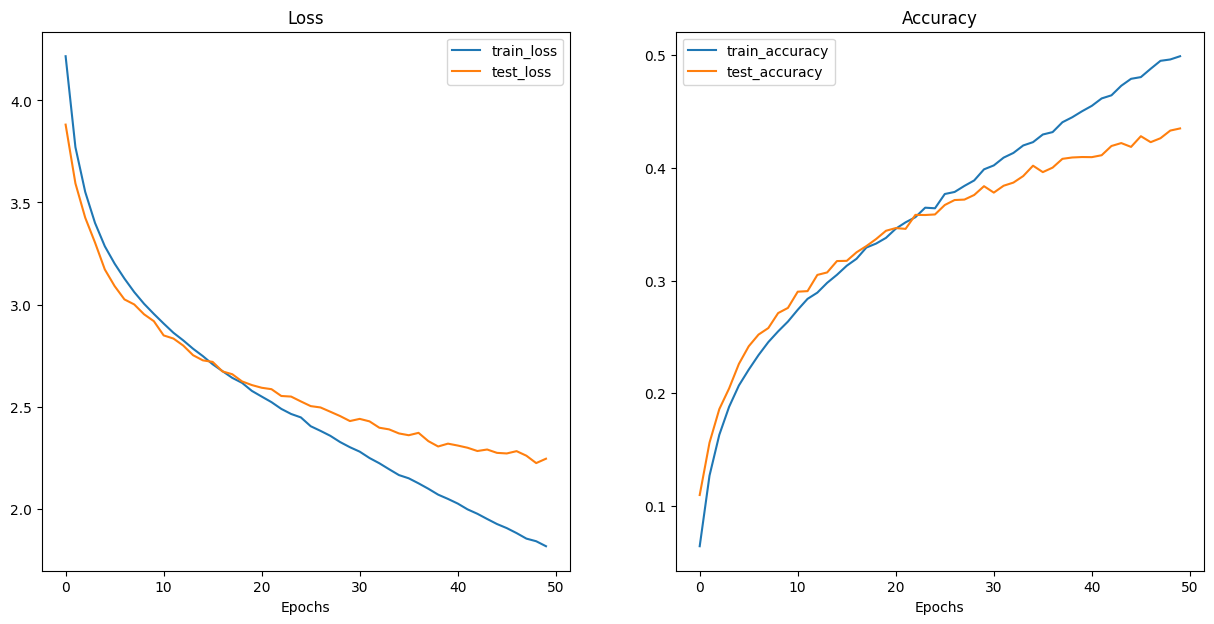

In [51]:
plot_loss_curves(results)

In [39]:
torch.save(obj=model.state_dict(), f="vit_v1.pth")